### Purpose
extension of 1D_spherical_intensity_slice plots --> instead of only do 1 vertical slice and projecting up, need to get some kind of range by doing vertical slices over the entire image   

once get it working for an entire image and makes sense, also try on the green and blue channels, then try to run on different time stamps  

pipeline: 
predefine a grid of lat/lon on my baseline altitude projection (240km), then project the entire grid up at once to each altitude, then pull out vertical slices by the points corresponding to the original grid, then getting the intensities at each one of those slices, and then calculate the 3 metrics (diff of pure maximums, diff of poly fit maximums, cross-corr lag) 


GOAL: for 1 time stamp, for each vertical sector/longiutde slide, get a plot in altitude vs SSD(or another similarity metric ie cross corr) giving a range of the best altitudes for that particular longitude sector --> do this for each longitude sector for 1 time stamp so get however many plots

_________________________________________________________________________________________________________________________________________

### NEW GENERAL BASELINE / CSTS FOR TESTING 
#### (should hold regardless of extending to a larger problem or not):
testing altitudes:  
h_target_arr = [130000, 140000, 150000, 160000, 170000, 180000, 190000, 200000, 210000, 220000, 230000, 240000, 250000, 260000, 270000, 280000, 290000, 300000]

baseline altitude chosen to determine the initial (lat, lon) arrays + initial bounding box to project up/down to each altitude:
(choose an altitude that is relatively between all the altitudes to test to minimize error from projections):  
200km 

baseline bounding box  @ 200km: (these are the bounds for where the aurora is in each frame for each site
fsmi:  
latmin: 60.5  
latmax: 67.5  
lonmin: 241.5  
lonmax: 262.5  
  
yknf:  
latmin: 60  
latmax: 68.5  
lonmin: 240  
lonmax: 265  

total bounding box is the union of these 2 bounding box (so the 1 box can "see" / cover all of the aurora in YKNF and FSMI):  
lat_box_min = 60  
lat_box_max = 68.5  
lon_box_min = 240  
lon_box_max = 265  

### CSTS FOR THE FIRST ITERATION 
#### (ie the first time stamp we are looking at to make sure the method works, before extending to larger problem)
date = datetime(2024,8,30)
hour = 5
time_index = 251



### Imports

In [29]:
import altitude_helper
import skymap_data_helper

import importlib
importlib.reload(altitude_helper)
from altitude_helper import *

# for interpolation
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation

import os # folder stuff 

import threading
import time 

from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from functools import partial
from tqdm.notebook import tqdm # since in jupyter

from matplotlib.path import Path # for polygon bounding box 

from scipy import signal # for sliding 1D median filter + correlation function for cross correlation
from scipy.optimize import curve_fit # try to fit gaussian to lat_grid, R_intensity_profile


### Data Loading

In [2]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


/home/molidae/Desktop/berkeley/STEVE2.0/skymap_data_helper.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["valid_end"] = df["valid_end"].fillna(pd.to_datetime(datetime.utcnow().date()))  # today at midnight UTC


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


### Helper Functions

In [3]:
# same as "new_get_lon_intensity_slice", just removed the "new" so no confusion
def get_lon_intensity_slice(lat_proj, lon_proj, rgb, # entire (az,el, rgb) for one camera reprojected to h_target
                         reproj_lat_arr_dict, reproj_lon_arr_dict, # reprojected latitude and longitude for the longitude line/sector
                         reproj_left_lat, reproj_left_lon,  # left side of reprojected bounding box
                         reproj_right_lat, reproj_right_lon,  # right side of reprojected bounding box
                         reproj_bottom_lat, reproj_bottom_lon,  # bottom side of reprojected bounding box
                         reproj_top_lat, reproj_top_lon, # top side of reprojected bounding box
                         site_name, time_index, new_h):
    """
    Given projected latitude and longitude arrays and a particular longitude to slice at (put this particular longitude is relative to 100km proj,
    put it into global_lon_arr as a single element array)
    Find the intensities for the latitudes along this longitude slice  (projected up to new_h, common across both cameras).
    Baseline global_lon_arr and global_lat_arr from 200km (og_h), then projected upwards to new_h. 

    Need to put baseline at 200km because want to see broad range of how the fsmi and yknf peak 
    Use 247.95 degrees longitude as baseline. 

    input:
        lat_proj = 2D projected latitude arr (output of project_lat_lon())
        lon_proj = 2D projected longitude arr (output of project_lat_lon())
        rgb = 3D rgb array (output of mod_plot_lat_lon()) (these are the raw rgb values from the skymap, need to be matched to the projected new projected lat/lon
        time_index = for naming purposes when plotting 
        site_name = for naming purposes when plotting
        og_h = 150,000 km the baseline for where we determined the best longitude slices and the best lat/lon box
        new_h = new height we've projected to for the interpolation (what lat_proj and lon_proj were projected to) 

    output:
        R_peak_lat_arr = 1D arr of all the latitudes that the R-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        G_peak_lat_arr = 1D arr of all the latitudes that the G-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        B_peak_lat_arr = 1D arr of all the latitudes that the B-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        lon_arr = 1D arr of all the longitudes corresponding in idx to the peak latitude arrays (should be same length as the other 3 returned arrays)
    """

    # just for printing 
    first_lon_key = next(iter(reproj_lon_arr_dict))
    num_lat_points = len(reproj_lon_arr_dict[first_lon_key])
    # print(f"\n====={new_h/1000.0}km PROJECTION=======")
    # print(
    #     f"Total {len(reproj_lon_arr_dict)} longitude(s) in dict: {list(reproj_lon_arr_dict.keys())}\n"
    #     f"Each longitude slice contains {num_lat_points} latitude points to interpolate.\n"
    # )
    
    # separate into R channel
    R = rgb[:,:, 0]
    #R = rgb[:,:, 1]

    # CHANGE: REPROJECT OUTSIDE THIS FUNCTION, SINCE REPROJECTION OF BOUNDING BOX AND SLICE SHOULD ONLY BE DONE WRT TO YKNF, THEN THE SAME BOX AND LINE SHOULD BE USED FOR INTERPOLATION ON BOTH YKNF AND FSMI
    # reproject the latitude slices and the bounding box for each projection --> already looping through all the lon slices here
    # all based on YKNF  
    # reproj_lat_arr_dict, reproj_lon_arr_dict, reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon, reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon = altitude_helper.project_lon_slices_and_box(global_lat_arr, global_lon_arr, # these are in degrees
                                                                                                                                                                                                                           #lat_max_box, lat_min_box, lon_max_box, lon_min_box, # also degrees
                                                                                                                                                                                                                           #lat_camera, lon_camera, og_h, new_h)
    # LEAVE THIS WHITESPACE ALONE
    original_lon_arr = reproj_lat_arr_dict.keys() # these keys should be the same as take from reproj_lon_arr_dict, and in degrees
    reproj_lon_slice_arr = reproj_lon_arr_dict.values() # this is array of arrays of longitude corresp. to each longitude of the original slices (should just be 1 value)
    reproj_lat_slice_arr = reproj_lat_arr_dict.values() # this is array of latitude for each longiutde in reproj_lon_slice


    # preallocate
    num_slices = len(original_lon_arr)
    R_peak_lat_arr = np.full(num_slices, np.nan)
    R_lon_arr = np.full(num_slices, np.nan)# longitudes that correspond to the peak latitude 
    #lon_buffer = 5 # no longer needed with the custom rectuangular box around which to interpolate the warped lon slices

    
    # defaults so the return never hits an unbound variable
    reproj_lat_slice = np.array([])
    R_intensity_profile = np.array([])

    for idx, (original_lon,reproj_lat_slice, reproj_lon_slice) in enumerate(zip(original_lon_arr, reproj_lat_slice_arr, reproj_lon_slice_arr)):
        # restrict reproj_lon/lat_slice to only be within the bounding box (don't care outside of the bounding box)
        slice_in_box_mask = (reproj_lat_slice >= np.min(reproj_bottom_lat)) & (reproj_lat_slice <= np.min(reproj_top_lat))
        reproj_lon_slice = reproj_lon_slice[slice_in_box_mask]
        reproj_lat_slice = reproj_lat_slice[slice_in_box_mask]
        

        # print(f"reproj lon slice = reprojected longitude corresponding to the same az/el pair: {reproj_lon_slice}")

        
        # plot the reprojected longitude slice line and the reprojected bounding box
        alpha = 5
        beta = 5
        rgb_adjusted = cv2.convertScaleAbs(rgb, alpha=alpha, beta=beta) # make aurora easier to see on background

        # remove plotting to speed up code
        # altitude_helper.plot_lon_slice_bounding_box(lat_proj, lon_proj, 
        #                                             reproj_lat_slice, reproj_lon_slice, #slice
        #                                             reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon, #bounding box
        #                                             reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon, #bounding box
        #                                             rgb_adjusted, time_index, site_name, new_h, 
        #                                             picket=False) # set picket=False so no zoomed in plotting view

        ## CHANGED SLICE MASK SO ITS PROPERLY CENTERED AND NOT JUST AN ARBITRARY CUTOFF 
        # looks at the max/min of all the points in the reprojected line and draws a box with a 1 degree buffer around them, preventing arbitrary cutoff of the actual projection line based on the origin 5 degree buffer
        #slice_mask = np.abs(lon_proj - original_lon) <= lon_buffer # might need to change this threshold depending on warp in projection

        if reproj_lon_slice.size == 0:
            R_intensity_profile = np.full(0, np.nan)
            continue
        pad = 1.0
        lon_lo = np.nanmin(reproj_lon_slice) - pad
        lon_hi = np.nanmax(reproj_lon_slice) + pad
        lat_lo = np.nanmin(reproj_lat_slice) - pad
        lat_hi = np.nanmax(reproj_lat_slice) + pad
        slice_mask = ((lon_proj >= lon_lo) & (lon_proj <= lon_hi) &
                      (lat_proj >= lat_lo) & (lat_proj <= lat_hi))
        
        
        lon_slice_points = lon_proj[slice_mask]
        lat_slice_points = lat_proj[slice_mask]
        R_slice_values = R[slice_mask] #already flattened 

        # get lat and lon slices over which to interpolate in the right shape 
        flattened_points = np.column_stack((lat_slice_points.flatten(), lon_slice_points.flatten())) # (N,2) pairs of (lat, lon)

        # masks for NaNs in R, G, and B channels separately (basically remove the NaNs and infinite values if there is) --> where the projected lat, lon, or rgb values corresponding to pixel are NaNs
        nan_mask_R = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(R_slice_values))
        points_R_clean = flattened_points[nan_mask_R]
        values_R_clean = R_slice_values[nan_mask_R]

        

        # get interpolation locations (these are just the (lat,lon) pairs from the reprojected longitude slices
        interp_locations = np.column_stack((reproj_lat_slice, reproj_lon_slice))

        # lon offsets to evaluate (e.g., -0.2, -0.1, 0.0, +0.1, +0.2 degrees) --> more techncially accurate to use km distance, bc these will not be the same "distance" / tracking the same points on the aurora as projecting up, the aurora spreads out so will be averaging over smaller vertical sector of the aurora
        lon_offsets = np.arange(-0.2, 0.25, 0.1)  # 5 parallel slices
        
        if len(points_R_clean) >= 3 and len(values_R_clean) >= 3:   # minimum for 2D linear interpolation
            # stack all shifted (lat, lon) target evaluation coordinates
            all_shifted_locs = np.vstack([
                np.column_stack((reproj_lat_slice, reproj_lon_slice + d_lon)) 
                for d_lon in lon_offsets
            ])

            # 1 griddata call for all offset paths simultaneously
            all_interp_values = griddata(points_R_clean, values_R_clean, all_shifted_locs, method='linear')

            # reshape into (num_offsets, numlatpoints) and average across offset slices
            reshaped_profiles = all_interp_values.reshape(len(lon_offsets), len(reproj_lat_slice))
            R_intensity_profile = np.nanmean(reshaped_profiles, axis=0)
        else:
            R_intensity_profile = np.full(len(interp_locations), np.nan)  # or 0

        

   # print(f"reproj lat slice arr: {reproj_lat_slice_arr}")
    #lat_grid = list(reproj_lat_arr_dict.values())[0]
    lat_grid = reproj_lat_slice
    # print(f"{site_name}{new_h} lat grid: {yknf_lat_grid}")
    # print(f"{site_name}{new_h} intensity grid: {R_intensity_profile}")
    
    return lat_grid, R_intensity_profile
    

In [4]:
### different types of fit

def fit_polynomial(site, lat_grid, R_intensity_profile, degree=7):
    # clean NaNs and Infinities
    valid_mask = np.isfinite(lat_grid) & np.isfinite(R_intensity_profile)
    x_data = np.array(lat_grid)[valid_mask]
    y_data = np.array(R_intensity_profile)[valid_mask]

    if len(x_data) < degree + 1:
        print(f"Error: Not enough valid points ({len(x_data)}) for degree {degree} fit.")
        return np.nan

    # fit Polynomial
    coefficients = np.polyfit(x_data, y_data, degree)
    poly_function = np.poly1d(coefficients)

    x_fit = np.linspace(np.min(x_data), np.max(x_data), 500)
    y_fit = poly_function(x_fit)

    # # plotting
    # plt.figure(figsize=(8, 5))
    # plt.scatter(x_data, y_data, color='blue', alpha=0.6, label='Raw Data')
    # plt.plot(x_fit, y_fit, color='red', linewidth=2.5, label=f'Degree {degree} Fit')
    # plt.legend()
    # plt.title(f'{site} Degree {degree} Polynomial Fit')
    # plt.xlabel('Latitude (deg)')
    # plt.ylabel('R-Channel Intensity')
    # plt.grid(True, alpha=0.3)
    # plt.show()

    # calculate cirtla points strictly in domain [min(x), max(x)]
    x_min, x_max = np.min(x_data), np.max(x_data)
    derivative = np.polyder(poly_function)
    critical_points = np.roots(derivative)

    # only keep real roots in boundary range
    real_critical_points = critical_points[
        np.isreal(critical_points) & 
        (critical_points.real >= x_min) & 
        (critical_points.real <= x_max)
    ].real

    # include boundary points (local max might occur at data endpoints)
    candidate_x = np.append(real_critical_points, [x_min, x_max])
    candidate_y = poly_function(candidate_x)

    # peak Max Latitude
    max_idx = np.argmax(candidate_y)
    max_latitude = candidate_x[max_idx]
    max_intensity = candidate_y[max_idx]

    return x_fit, y_fit, max_latitude, max_intensity

    
def cross_correlation(yknf_lat_grid, fsmi_lat_grid, yknf_R_intensity_profile, fsmi_R_intensity_profile):
    """
    Computes cross-correlation and latitude shift between YKNF and FSMI intensity profiles.
    """
    # mask nans from both intensities (y vals) 
    valid_mask = np.isfinite(yknf_R_intensity_profile) & np.isfinite(fsmi_R_intensity_profile)
    
    if np.sum(valid_mask) < 3:
        print("Error: Not enough valid points to compute cross-correlation.")
        return np.nan, np.nan, np.nan

    yknf_clean = yknf_R_intensity_profile[valid_mask]
    fsmi_clean = fsmi_R_intensity_profile[valid_mask]
    lat_clean = yknf_lat_grid[valid_mask]

    # lat_step using latitude grid (xval step)
    lat_step = lat_clean[1] - lat_clean[0]

    # mean-subtract signals to eliminate static baseline offsets
    yknf_norm = yknf_clean - np.mean(yknf_clean)
    fsmi_norm = fsmi_clean - np.mean(fsmi_clean)

    # cross-correlation
    correlation = np.correlate(yknf_norm, fsmi_norm, mode='full')
    
    # Normalize correlation coefficient to range [-1, 1]
    norm_factor = np.sqrt(np.sum(yknf_norm**2) * np.sum(fsmi_norm**2))
    if norm_factor > 0:
        correlation = correlation / norm_factor

    # calculate point lag and latitude lag
    max_corr_index = np.argmax(correlation)
    zero_lag_index = len(fsmi_clean) - 1
    point_lag = max_corr_index - zero_lag_index
    
    latitude_lag = point_lag * lat_step
    max_corr_val = correlation[max_corr_index]

    # print(f"Amt of lag bw FSMI and YKNF in latitude: {latitude_lag:.4f}°")
    # print(f"Max correlation value: {max_corr_val:.3f}")

    return latitude_lag, max_corr_val, correlation[zero_lag_index] 



In [5]:
def plot_lon_intensity_slice(site, lat_grid, R_intensity_interp, lon, h):
    """ 
    Given the latitudes and the R channel pixel intensities along some longitude slice for just one site, 
    make a plot showing how the intensity varies across the latitudes for one slice.

    inputs:
        site: string of site name for plot title (YKNF, FSMI)
        lat_grid: array of latitudes we interpolated to in get_intensity_slice for one site (yknf or fsmi)
        R_intensity_interp: array of intensities for each of the latitudes above (len of R intensity = len lat grid)
        lon: the longitude slice for which we stepped along and looked at the brightnesses at diff latitudes
        h: altitude projected to for this longitude slice

    outputs:
        plot
    """
    plt.figure(figsize=(8, 5))
    
    # Plot  intensity profile
    plt.plot(np.array(lat_grid).flatten(), np.array(R_intensity_interp).flatten(), label=site, color='red', marker='o', linestyle='-')
        
    plt.xlabel("Latitude (deg)")
    plt.ylabel(f"R-channel intensity")
    plt.title(f"{site} {h/1000.0}km: R-channel intensity vs Latitude at longitude {lon:.2f}°")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
def plot_lon_intensity_slices(yknf_lat_grid, yknf_R_intensity_interp, 
                        fsmi_lat_grid, fsmi_R_intensity_interp,
                        lon, h, bsub=False):
    """ 
    Given the latitudes and the R channel pixel intensities along some longitude slice for both yknf and fsmi, 
    make a plot showing how the intensity varies across the latitudes for each of the fsmi and yknf slices

    inputs:
        yknf_lat_grid: array of latitudes we interpolated to in get_intensity_slice for yknf
        yknf_R_intensity_interp: array of intensities for each of the latitudes above (len of R intensity = len lat grid)
        fsmi_lat_grid: equiv.
        fsmi_R_intensity_interp: equiv.
        lon: the longitude slice for which we stepped along and looked at the brightnesses at diff latitudes
        h: altitude projected to for this longitude slice

    outputs:
        plot
    """
    plt.figure(figsize=(8, 5))
    
    # Plot YKNF intensity profile
    plt.plot(np.array(yknf_lat_grid).flatten(), np.array(yknf_R_intensity_interp).flatten(), label='YKNF', color='red', marker='o', linestyle='-')
    
    # Plot FSMI intensity profile
    plt.plot(np.array(fsmi_lat_grid).flatten(), np.array(fsmi_R_intensity_interp).flatten(), label='FSMI', color='blue', marker='x', linestyle='--')
    
    plt.xlabel("Latitude (deg)")
    plt.ylabel("R-channel intensity")
    if bsub:
        plt.title(f"BSUB {h/1000.0}km: R-channel intensity vs Latitude at longitude {lon:.2f}°")
    else:
        plt.title(f"{h/1000.0}km: R-channel intensity vs Latitude at longitude {lon:.2f}°")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    

In [7]:
def plot_fit_data(yknf_lat_grid, yknf_R_intensity_interp,
                  fsmi_lat_grid, fsmi_R_intensity_interp,
                  lon, h, latitude_lag, max_corr_val):
    
    # flatten grid data 
    yknf_lat_flat = np.array(yknf_lat_grid).flatten()
    yknf_int_flat = np.array(yknf_R_intensity_interp).flatten()
    fsmi_lat_flat = np.array(fsmi_lat_grid).flatten()
    fsmi_int_flat = np.array(fsmi_R_intensity_interp).flatten()

    # pure data maximums
    yknf_intensity_max = np.max(yknf_int_flat)
    yknf_lat_max = yknf_lat_flat[np.argmax(yknf_int_flat)]

    fsmi_intensity_max = np.max(fsmi_int_flat)
    fsmi_lat_max = fsmi_lat_flat[np.argmax(fsmi_int_flat)]
    
    plt.figure(figsize=(10, 6))

    # calculate polynomial fits
    yknf_x_fit, yknf_y_fit, yknf_max_latitude_poly, yknf_max_intensity_poly = fit_polynomial("YKNF", yknf_lat_grid, yknf_R_intensity_interp, degree=7)
    fsmi_x_fit, fsmi_y_fit, fsmi_max_latitude_poly, fsmi_max_intensity_poly = fit_polynomial("FSMI", fsmi_lat_grid, fsmi_R_intensity_interp, degree=7)
    
    # scatter raw points
    plt.scatter(yknf_lat_flat, yknf_int_flat, color='red', alpha=0.3, marker='o', label='YKNF Data')
    plt.scatter(fsmi_lat_flat, fsmi_int_flat, color='blue', alpha=0.3, marker='o', label='FSMI Data')
    
    # fit lines
    plt.plot(yknf_x_fit, yknf_y_fit, label="YKNF poly fit", color='red')
    plt.plot(fsmi_x_fit, fsmi_y_fit, label="FSMI poly fit", color='blue')

    # maximum markers
    plt.scatter(yknf_lat_max, yknf_intensity_max, color='red', marker='X', label="YKNF data max", s=150)
    plt.scatter(yknf_max_latitude_poly, yknf_max_intensity_poly, color='red', marker='^', label="YKNF poly max", s=150)
    
    plt.scatter(fsmi_lat_max, fsmi_intensity_max, color='blue', marker='X', label="FSMI data max", s=150)
    plt.scatter(fsmi_max_latitude_poly, fsmi_max_intensity_poly, color='blue', marker='^', label="FSMI poly max", s=150)

    # ------------------ CROSS CORR LAG VISUALIZATION ------------------
    if np.isfinite(latitude_lag):
        # Anchor the shift starting at the FSMI peak latitude
        x_start = fsmi_max_latitude_poly
        x_end = fsmi_max_latitude_poly + latitude_lag
        
        # Place arrow slightly above the maximum intensity
        peak_y = max(yknf_max_intensity_poly, fsmi_max_intensity_poly) * 1.08
        
        # shaded region from peak of fsmi polynomial fit to a length of latitude equal to latitude_lag 
        plt.axvspan(min(x_start, x_end), max(x_start, x_end), color='purple', alpha=0.15, label='CC Lag')
    
        # 2. arrow for direction + mag of lag 
        plt.annotate(
            '', 
            xy=(x_end, peak_y), 
            xytext=(x_start, peak_y),
            arrowprops=dict(arrowstyle="<->", color="purple", lw=2)
        )
    
        # text label
        plt.text(
            (x_start + x_end) / 2, peak_y * 1.02, 
            f"Lag: {latitude_lag:+.3f}°", 
            fontsize=9, fontweight='bold', color='purple', ha='center'
        )
    # ------------------------------------------------------------------------

    plt.xlabel("Latitude (deg)")
    plt.ylabel("R-channel intensity")
    plt.title(f"{h/1000.0}km - YKNF vs FSMI poly fits & CC Lag - lon{lon:.2f}")
    plt.legend(fontsize='small', bbox_to_anchor=(1.02, 1.0), loc='upper right', borderaxespad=0)
    plt.grid(True)
    plt.tight_layout(rect=[0, 0, 0.85, 1.0])
    plt.show()

### Do Over Full Image
Do 3 possible different ways to compare FSMI and YKNF curves:
1. pure difference between latitudes of the maximum intensities, smallest diff wins
2. pure difference between latitudes of the maximum intensities after polynomial fit (ignores outliers), smallest diff wins
3. cross correlation to get latitude lag  

Only project up to one altitude, and do for all the longitude slices in the grid and getting all the metrics--> after this works, then start projecting up to different altitudes and seeing it the results are consistent. 

Define an entire grid of lat/lon pairs for each line in longitude going over the entire image
Project the entire (lat,lon) grid up to a particular altitude (starting at 130km, if it works here, then do it for other altitude projections to get a definitive altitude determination. In order to project entire thing up, need to do the reverse projection to get (az,el) for all of the pairs in the longitude line, then project back up (all in YKNF's camera). --> maybe do the projection and interpolation of the entire grid all at once rather than continually looping (computationally is better). 

Different plots to make:
For each slice, will get a similarity plot, need to make sure the similarity plot does not vary too much across the slices & get an altitude determination across each slice. 

maybe can do the same thing with FSMI as a reference to confirm that everything is working. 

# Altitude Determinations for Multiple Sectors
Looping over multiplical vertical sector to get an altitude determination for "each longitude"  
Also serves as a sanity check that longitude sectors next to each other should have the same   

## Ground Rule
- create a lat/lon grid with 0.05 spacing

Looping through everything-- all altitudes to test, all slices (do 1 degree apart for speed at first), and get an altitude determination for each of the altitudes. Ideally slices that are next to eachother should have a similar altitude determination since there shouldnt be a crazy shift. If the results are crazy, go back and run to get all plots to see where things might be breaking. 

In [8]:
# # target height for single altitude processing
# h_target_arr = [130000, 135000, 140000, 145000, 150000, 155000, 160000, 165000, 170000, 175000, 180000, 185000, 190000, 195000, 200000, 205000, 210000, 215000, 220000, 225000, 230000, 235000, 240000, 245000, 250000, 255000, 260000, 265000, 270000, 275000, 280000, 285000, 290000, 295000, 300000, 305000, 310000, 315000,320000,325000, 330000, 335000, 340000, 345000, 350000]

# h_target = h_target_arr[0]

# # altitude of initial image for (lat, lon) 
# H_REF = 240000
# lat_box_min = 59.5 # lowered bc looked like fsmi getting cut off
# lat_box_max = 70
# lon_box_min = 240
# lon_box_max = 268

# lat_cam_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
# lon_cam_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
# full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
# full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

# lat_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
# lon_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
# full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
# full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]


# #--------get rgb values for yknf and fsmi for plotting-----------#
# time_index = 251
# R_yknf = yknf_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
# G_yknf = yknf_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
# B_yknf = yknf_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
# rgb_yknf = np.stack([R_yknf, G_yknf, B_yknf], axis=-1)

# R_fsmi = fsmi_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
# G_fsmi = fsmi_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
# B_fsmi = fsmi_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
# rgb_fsmi = np.stack([R_fsmi, G_fsmi, B_fsmi], axis=-1)


# # base grid over the common bounding box --> this is all defined in the YKNF 240km proj world 
# lat_step = 1
# lon_step = 1
# # lat_step = 0.05
# # lon_step = 0.05

# global_lat_arr = np.arange(lat_box_min, lat_box_max + lat_step, lat_step)
# global_lon_arr = np.arange(lon_box_min, lon_box_max + lon_step, lon_step)

# # 2D grid of lat,lon
# lon_grid, lat_grid = np.meshgrid(global_lon_arr, global_lat_arr, indexing="ij")



# # project full yknf and fsmi images to target altitude ONLY ONCE
# yknf_lat_proj_arr, yknf_lon_proj_arr = (
#     altitude_helper.new_spherical_project_lat_lon(
#         full_azimuth_yknf,
#         full_elevation_yknf,
#         lat_cam_yknf,
#         lon_cam_yknf,
#         h_target,
#     )
# )

# fsmi_lat_proj_arr, fsmi_lon_proj_arr = (
#     altitude_helper.new_spherical_project_lat_lon(
#         full_azimuth_fsmi,
#         full_elevation_fsmi,
#         lat_cam_fsmi,
#         lon_cam_fsmi,
#         h_target,
#     )
# )

# # defining bounding box 
# lat_box_arr = np.arange(lat_box_min, lat_box_max + lat_step, lat_step)
# lon_box_arr = np.arange(lon_box_min, lon_box_max + lon_step, lon_step)

# reproj_left_lat, reproj_left_lon = lat_box_arr, np.full_like(
#     lat_box_arr, fill_value=lon_box_min
# )
# reproj_right_lat, reproj_right_lon = lat_box_arr, np.full_like(
#     lat_box_arr, fill_value=lon_box_max
# )
# reproj_bottom_lat, reproj_bottom_lon = (
#     np.full_like(lon_box_arr, fill_value=lat_box_min),
#     lon_box_arr,
# )
# reproj_top_lat, reproj_top_lon = (
#     np.full_like(lon_box_arr, fill_value=lat_box_max),
#     lon_box_arr,
# )

# # best altitude

# for h_target in h_target_arr:
#     # metric tracking arrays, reset after doing all the longitude slices for one projection
#     max_lat_diff = []
#     poly_lat_diff = []
#     cross_corr_lat_lag = []
#     yknf_poly_max = []
#     fsmi_poly_max = []
#     yknf_max = []
#     fsmi_max = []
#     zero_lag_corr_arr = []
#     # loop through all of the "longitudes" for each slice 
#     print(f"Projecting to altitude: {h_target}")
#     for current_lon in global_lon_arr:
        
#         # --- DYNAMIC PROJECTION OF BOX & SLICE LINE ---
#         if H_REF != h_target:
#             # Reproject line slice and bounding box from H_REF to h_target via YKNF perspective
#             (
#                 reproj_lat_arr_dict,
#                 reproj_lon_arr_dict,
#                 reproj_left_lat,
#                 reproj_left_lon,
#                 reproj_right_lat,
#                 reproj_right_lon,
#                 reproj_bottom_lat,
#                 reproj_bottom_lon,
#                 reproj_top_lat,
#                 reproj_top_lon,
#             ) = altitude_helper.project_lon_slices_and_box(
#                 global_lat_arr,
#                 [current_lon],
#                 lat_box_max,
#                 lat_box_min,
#                 lon_box_max,
#                 lon_box_min,
#                 lat_cam_yknf,
#                 lon_cam_yknf,
#                 H_REF,
#                 h_target,
#             )
#         else:
#             # If processing at H_REF baseline, keep straight geographic lines
#             reproj_lat_arr_dict = {current_lon: np.array(global_lat_arr)}
#             reproj_lon_arr_dict = {
#                 current_lon: np.full_like(global_lat_arr, fill_value=current_lon)
#             }
    
#             # Flat bounding box boundaries
#             lat_box_arr = np.arange(lat_box_min, lat_box_max + lat_step, lat_step)
#             lon_box_arr = np.arange(lon_box_min, lon_box_max + lon_step, lon_step)
    
#             reproj_left_lat, reproj_left_lon = lat_box_arr, np.full_like(lat_box_arr, fill_value=lon_box_min)
#             reproj_right_lat, reproj_right_lon = lat_box_arr, np.full_like(lat_box_arr, fill_value=lon_box_max)
#             reproj_bottom_lat, reproj_bottom_lon = np.full_like(lon_box_arr, fill_value=lat_box_min), lon_box_arr
#             reproj_top_lat, reproj_top_lon = np.full_like(lon_box_arr, fill_value=lat_box_max), lon_box_arr
    
#         # --- EXTRACT WARPED INTENSITY SLICES ---
#         yknf_lat_grid_slice, yknf_R_intensity_interp = get_lon_intensity_slice(
#             yknf_lat_proj_arr,
#             yknf_lon_proj_arr,
#             rgb_yknf,
#             reproj_lat_arr_dict,
#             reproj_lon_arr_dict,
#             reproj_left_lat,
#             reproj_left_lon,
#             reproj_right_lat,
#             reproj_right_lon,
#             reproj_bottom_lat,
#             reproj_bottom_lon,
#             reproj_top_lat,
#             reproj_top_lon,
#             "YKNF",
#             time_index,
#             h_target,
#         )
    
#         fsmi_lat_grid_slice, fsmi_R_intensity_interp = get_lon_intensity_slice(
#             fsmi_lat_proj_arr,
#             fsmi_lon_proj_arr,
#             rgb_fsmi,
#             reproj_lat_arr_dict,
#             reproj_lon_arr_dict,
#             reproj_left_lat,
#             reproj_left_lon,
#             reproj_right_lat,
#             reproj_right_lon,
#             reproj_bottom_lat,
#             reproj_bottom_lon,
#             reproj_top_lat,
#             reproj_top_lon,
#             "FSMI",
#             time_index,
#             h_target,
#         )
    
#         # polynomial fitting on sliced vertical profiles
#         try:
#             _, _, yknf_max_lat_poly, _ = fit_polynomial(
#                 "YKNF", yknf_lat_grid_slice, yknf_R_intensity_interp
#             )
#             _, _, fsmi_max_lat_poly, _ = fit_polynomial(
#                 "FSMI", fsmi_lat_grid_slice, fsmi_R_intensity_interp
#             )
#         except Exception as e:
#             yknf_max_lat_poly = np.nan
#             fsmi_max_lat_poly = np.nan
    
#         # cross-correlation between profiles along latitude
#         lat_lag, max_corr, zero_lag_corr = cross_correlation(
#             yknf_lat_grid_slice,
#             fsmi_lat_grid_slice,
#             yknf_R_intensity_interp,
#             fsmi_R_intensity_interp,
#         )
    
#         # find absolute maximum positions on raw slices (masking invalid entries)
#         if (
#             np.all(np.isnan(yknf_R_intensity_interp))
#             or len(yknf_R_intensity_interp) == 0
#         ):
#             yknf_max_lat = np.nan
#         else:
#             yknf_max_lat = yknf_lat_grid_slice[
#                 np.nanargmax(yknf_R_intensity_interp)
#             ]
    
#         if (
#             np.all(np.isnan(fsmi_R_intensity_interp))
#             or len(fsmi_R_intensity_interp) == 0
#         ):
#             fsmi_max_lat = np.nan
#         else:
#             fsmi_max_lat = fsmi_lat_grid_slice[
#                 np.nanargmax(fsmi_R_intensity_interp)
#             ]
    
#         # calculate differences and append metrics
#         max_lat_diff.append(yknf_max_lat - fsmi_max_lat)
#         poly_lat_diff.append(yknf_max_lat_poly - fsmi_max_lat_poly)
#         cross_corr_lat_lag.append(lat_lag)
#         yknf_poly_max.append(yknf_max_lat_poly)
#         fsmi_poly_max.append(fsmi_max_lat_poly)
#         yknf_max.append(yknf_max_lat)
#         fsmi_max.append(fsmi_max_lat)
#         zero_lag_corr_arr.append(zero_lag_corr)
    
#     plt.figure(figsize=(8, 5))
        
#     #plt.plot(global_lon_arr, np.abs(cross_corr_lat_lag), label="abs(max diff)", color='red', marker='o', linestyle='-')
#     plt.plot(global_lon_arr, cross_corr_lat_lag, label="max diff", color='green', marker='o', linestyle='-')
#     plt.plot(global_lon_arr, zero_lag_corr_arr, label="zero lag corr", color='blue',marker='o', linestyle='-')
#     plt.plot(global_lon_arr, poly_lat_diff, label="poly max diff", color='orange', marker='o', linestyle='-')
    
        
#     plt.xlabel(f"longitude (lon_240)")
#     plt.ylabel("lat lag bw intensity peaks")
#     plt.title(f"lon slice & lat lag")
#     plt.legend(fontsize="small")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

### Sped-Up Code --> Looping over the entire image

In [37]:
#================== SET UP VALUES ====================#
lat_cam_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_cam_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

lat_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]


#--------get rgb values for yknf and fsmi for plotting-----------#
time_index = 251
R_yknf = yknf_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
G_yknf = yknf_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
B_yknf = yknf_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
rgb_yknf = np.stack([R_yknf, G_yknf, B_yknf], axis=-1)

R_fsmi = fsmi_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
G_fsmi = fsmi_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
B_fsmi = fsmi_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
rgb_fsmi = np.stack([R_fsmi, G_fsmi, B_fsmi], axis=-1)


# change lat_step from 1.0 to 0.05 
lat_step = 0.05 
lon_step = 1.0

h_target_arr = [50000, 55000, 60000, 65000, 70000, 75000, 80000, 85000, 90000, 95000, 100000, 105000, 110000, 115000, 120000, 125000, 130000, 135000, 140000, 145000, 150000, 155000, 160000, 165000, 170000, 175000, 180000, 185000, 190000, 195000, 200000, 205000, 210000, 215000, 220000, 225000, 230000, 235000, 240000, 245000, 250000, 255000, 260000, 265000, 270000, 275000, 280000, 285000, 290000, 295000, 300000, 305000, 310000, 315000,320000,325000, 330000, 335000, 340000, 345000, 350000, 355000, 360000, 365000, 370000, 375000, 380000]

H_REF = 240000
lat_box_min = 59.5 # lowered bc looked like fsmi getting cut off
lat_box_max = 70
lon_box_min = 240
lon_box_max = 268

global_lat_arr = np.arange(lat_box_min, lat_box_max + lat_step, lat_step)
global_lon_arr = np.arange(lon_box_min, lon_box_max + lon_step, lon_step)

n_alts = len(h_target_arr)
n_lons = len(global_lon_arr)

# 2d arrays for storing cross corr, raw peak diff, and poly fit peak diff
zero_lag_matrix = np.full((n_alts, n_lons), np.nan)
lat_lag_matrix = np.full((n_alts, n_lons), np.nan)
raw_lat_diff_matrix = np.full((n_alts, n_lons), np.nan)
poly_lat_diff_matrix = np.full((n_alts, n_lons), np.nan)

for alt_idx, h_target in enumerate(h_target_arr):
    print(f"[{alt_idx+1}/{n_alts}] Processing altitude: {h_target/1000:.1f} km")

    # Projection updates
    yknf_lat_proj, yknf_lon_proj = altitude_helper.new_spherical_project_lat_lon(
        full_azimuth_yknf, full_elevation_yknf, lat_cam_yknf, lon_cam_yknf, h_target
    )
    fsmi_lat_proj, fsmi_lon_proj = altitude_helper.new_spherical_project_lat_lon(
        full_azimuth_fsmi, full_elevation_fsmi, lat_cam_fsmi, lon_cam_fsmi, h_target
    )

    if H_REF != h_target:
        (
            reproj_lat_dict, reproj_lon_dict,
            reproj_left_lat, reproj_left_lon,
            reproj_right_lat, reproj_right_lon,
            reproj_bottom_lat, reproj_bottom_lon,
            reproj_top_lat, reproj_top_lon,
        ) = altitude_helper.project_lon_slices_and_box(
            global_lat_arr, global_lon_arr,
            lat_box_max, lat_box_min, lon_box_max, lon_box_min,
            lat_cam_yknf, lon_cam_yknf, H_REF, h_target
        )
    else:
        reproj_lat_dict = {lon: np.array(global_lat_arr) for lon in global_lon_arr}
        reproj_lon_dict = {lon: np.full_like(global_lat_arr, lon) for lon in global_lon_arr}
        lat_box_arr = np.arange(lat_box_min, lat_box_max + lat_step, lat_step)
        lon_box_arr = np.arange(lon_box_min, lon_box_max + lon_step, lon_step)
        reproj_left_lat, reproj_left_lon = lat_box_arr, np.full_like(lat_box_arr, fill_value=lon_box_min)
        reproj_right_lat, reproj_right_lon = lat_box_arr, np.full_like(lat_box_arr, fill_value=lon_box_max)
        reproj_bottom_lat, reproj_bottom_lon = np.full_like(lon_box_arr, fill_value=lat_box_min), lon_box_arr
        reproj_top_lat, reproj_top_lon = np.full_like(lon_box_arr, fill_value=lat_box_max), lon_box_arr

    # Slice loop
    for lon_idx, current_lon in enumerate(global_lon_arr):
        yknf_lat_slice, yknf_R_interp = get_lon_intensity_slice(
            yknf_lat_proj, yknf_lon_proj, rgb_yknf,
            {current_lon: reproj_lat_dict[current_lon]},
            {current_lon: reproj_lon_dict[current_lon]},
            reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon,
            reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon,
            "YKNF", time_index, h_target
        )

        fsmi_lat_slice, fsmi_R_interp = get_lon_intensity_slice(
            fsmi_lat_proj, fsmi_lon_proj, rgb_fsmi,
            {current_lon: reproj_lat_dict[current_lon]},
            {current_lon: reproj_lon_dict[current_lon]},
            reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon,
            reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon,
            "FSMI", time_index, h_target
        )

        valid_yknf = np.count_nonzero(~np.isnan(yknf_R_interp))
        valid_fsmi = np.count_nonzero(~np.isnan(fsmi_R_interp))

        if valid_yknf >= 5 and valid_fsmi >= 5:
            # print(f"lon: {current_lon}")
            # ---- cross corr ----- #
            try:
                lat_lag, max_corr, zero_lag_corr = cross_correlation(
                    yknf_lat_slice, fsmi_lat_slice, yknf_R_interp, fsmi_R_interp
                )
                zero_lag_matrix[alt_idx, lon_idx] = zero_lag_corr
                lat_lag_matrix[alt_idx, lon_idx] = lat_lag

                # print(f"lat_lag: {lat_lag}")
                # print(f"zero_lag_corr: {zero_lag_corr}")
            except Exception:
                print("Not enough valid YKNF and valid FSMI interpolation points\n")
                pass

            # ---- raw intensity peak lat diff ----- #
            yknf_max_lat = yknf_lat_slice[np.nanargmax(yknf_R_interp)]
            fsmi_max_lat = fsmi_lat_slice[np.nanargmax(fsmi_R_interp)]
            raw_lat_diff_matrix[alt_idx, lon_idx] = np.abs(yknf_max_lat - fsmi_max_lat)
            # print(f"raw_lat_diff: {np.abs(yknf_max_lat - fsmi_max_lat)}")

            # ---- poly fit peak lat diff ----- #
            try:
                _, _, yknf_max_lat_poly, _ = fit_polynomial("YKNF", yknf_lat_slice, yknf_R_interp)
                _, _, fsmi_max_lat_poly, _ = fit_polynomial("FSMI", fsmi_lat_slice, fsmi_R_interp)
                
                if not (np.isnan(yknf_max_lat_poly) or np.isnan(fsmi_max_lat_poly)):
                    poly_lat_diff_matrix[alt_idx, lon_idx] = np.abs(yknf_max_lat_poly - fsmi_max_lat_poly)

                # print(f"poly_lat_diff: {np.abs(yknf_max_lat_poly - fsmi_max_lat_poly)}\n")
            except Exception:
                pass
        else:
            print(f"Not enough valid yknf and yknf fsmi after interpolation and masking for lon{current_lon}")

[1/67] Processing altitude: 50.0 km


/tmp/ipykernel_223402/2705845186.py:141: RuntimeWarning: Mean of empty slice
  R_intensity_profile = np.nanmean(reshaped_profiles, axis=0)
/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.p

Not enough valid yknf and yknf fsmi after interpolation and masking for lon266.0
Not enough valid yknf and yknf fsmi after interpolation and masking for lon267.0
Not enough valid yknf and yknf fsmi after interpolation and masking for lon268.0
[2/67] Processing altitude: 55.0 km


/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.py

Not enough valid yknf and yknf fsmi after interpolation and masking for lon265.0
Not enough valid yknf and yknf fsmi after interpolation and masking for lon266.0
Not enough valid yknf and yknf fsmi after interpolation and masking for lon267.0
Not enough valid yknf and yknf fsmi after interpolation and masking for lon268.0
[3/67] Processing altitude: 60.0 km


...

[45/67] Processing altitude: 270.0 km


/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)


[46/67] Processing altitude: 275.0 km


/tmp/ipykernel_223402/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)


[47/67] Processing altitude: 280.0 km
[48/67] Processing altitude: 285.0 km
[49/67] Processing altitude: 290.0 km
[50/67] Processing altitude: 295.0 km
[51/67] Processing altitude: 300.0 km
[52/67] Processing altitude: 305.0 km
[53/67] Processing altitude: 310.0 km
[54/67] Processing altitude: 315.0 km
[55/67] Processing altitude: 320.0 km
[56/67] Processing altitude: 325.0 km
[57/67] Processing altitude: 330.0 km
[58/67] Processing altitude: 335.0 km
[59/67] Processing altitude: 340.0 km
[60/67] Processing altitude: 345.0 km
[61/67] Processing altitude: 350.0 km
[62/67] Processing altitude: 355.0 km
[63/67] Processing altitude: 360.0 km
[64/67] Processing altitude: 365.0 km
[65/67] Processing altitude: 370.0 km
[66/67] Processing altitude: 375.0 km
[67/67] Processing altitude: 380.0 km


In [38]:
best_alt_zero_lag = np.full(n_lons, np.nan)
best_alt_raw_peak = np.full(n_lons, np.nan)
best_alt_poly_peak = np.full(n_lons, np.nan)

for lon_idx in range(n_lons):
    # Cross-Correlation -> Maximization
    corr_col = zero_lag_matrix[:, lon_idx]
    if not np.all(np.isnan(corr_col)):
        best_alt_zero_lag[lon_idx] = h_target_arr[np.nanargmax(corr_col)] / 1000.0

    # Raw Peak Difference -> Minimization
    raw_col = raw_lat_diff_matrix[:, lon_idx]
    if not np.all(np.isnan(raw_col)):
        best_alt_raw_peak[lon_idx] = h_target_arr[np.nanargmin(raw_col)] / 1000.0

    # Polynomial Peak Difference -> Minimization
    poly_col = poly_lat_diff_matrix[:, lon_idx]
    if not np.all(np.isnan(poly_col)):
        best_alt_poly_peak[lon_idx] = h_target_arr[np.nanargmin(poly_col)] / 1000.0

# Print direct comparison across all three metrics
print(f"{'Lon (°)':>8} | {'Zero-Lag Alt (km)':>18} | {'Raw Peak Alt (km)':>18} | {'Poly Peak Alt (km)':>18}")
print("-" * 72)
for lon, a_corr, a_raw, a_poly in zip(global_lon_arr, best_alt_zero_lag, best_alt_raw_peak, best_alt_poly_peak):
    print(f"{lon:8.1f} | {a_corr:18.1f} | {a_raw:18.1f} | {a_poly:18.1f}")

 Lon (°) |  Zero-Lag Alt (km) |  Raw Peak Alt (km) | Poly Peak Alt (km)
------------------------------------------------------------------------
   240.0 |               55.0 |               50.0 |               55.0
   241.0 |              380.0 |              255.0 |               50.0
   242.0 |              380.0 |              180.0 |              380.0
   243.0 |              365.0 |              330.0 |              285.0
   244.0 |              375.0 |              300.0 |              365.0
   245.0 |              380.0 |              170.0 |              320.0
   246.0 |              380.0 |              250.0 |              360.0
   247.0 |              380.0 |              230.0 |              280.0
   248.0 |              275.0 |              205.0 |              270.0
   249.0 |              245.0 |              250.0 |              250.0
   250.0 |              330.0 |              245.0 |              230.0
   251.0 |              275.0 |              195.0 |           

In [41]:
#### NOT USING THIS BC SIDEWAYS LABELS CONFUSING #####


# # Create x-axis string labels in the format "lon_240"
# x_labels = [f"{int(lon)}" for lon in global_lon_arr]

# plt.figure(figsize=(12, 6))

# # Plot all 3 metrics on a single axis
# plt.plot(x_labels, best_alt_zero_lag, marker='o', color='red', linewidth=2, label='Zero-Lag Cross-Corr')
# plt.plot(x_labels, best_alt_raw_peak, marker='s', color='blue', linewidth=2, linestyle='--', label='Raw Intensity Peak Diff')
# plt.plot(x_labels, best_alt_poly_peak, marker='^', color='green', linewidth=2, linestyle='-.', label='Polynomial Peak Diff')

# # Labels and Styling
# plt.xlabel('Longitude Slice (240km)', fontsize=15, labelpad=10)
# plt.ylabel('Altitude (km)', fontsize=15)
# plt.title('Altitude Determination Comparison by Longitude Slice', fontsize=20, pad=15)

# plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for clean spacing
# plt.grid(True, linestyle=':', alpha=0.6)
# plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

# # Adjust y-axis limits with padding around the projection bounds
# plt.ylim(np.nanmin(h_target_arr)/1000.0 - 10, np.nanmax(h_target_arr)/1000.0 + 10)

# plt.tight_layout()
# plt.show()

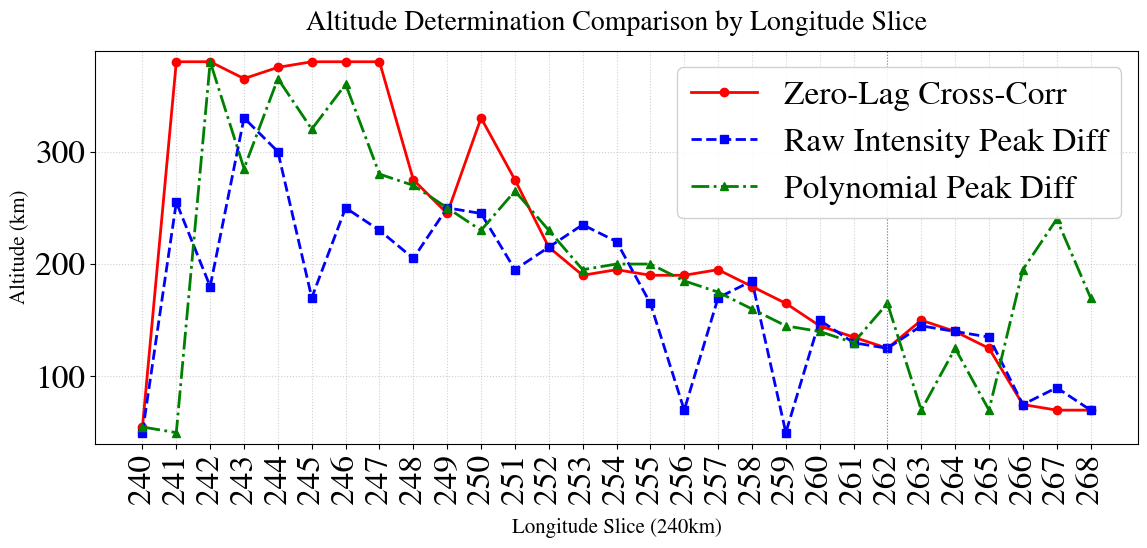

In [42]:
#### CHANGED TO USE HORIZONTAL LABELS #####

plt.figure(figsize=(12, 6))

# Plot all 3 metrics on a single axis, against the numeric longitudes
plt.plot(global_lon_arr, best_alt_zero_lag, marker='o', color='red', linewidth=2, label='Zero-Lag Cross-Corr')
plt.plot(global_lon_arr, best_alt_raw_peak, marker='s', color='blue', linewidth=2, linestyle='--', label='Raw Intensity Peak Diff')
plt.plot(global_lon_arr, best_alt_poly_peak, marker='^', color='green', linewidth=2, linestyle='-.', label='Polynomial Peak Diff')

# Labels and Styling
plt.xlabel('Longitude Slice (240km)', fontsize=15, labelpad=10)
plt.ylabel('Altitude (km)', fontsize=15)
plt.title('Altitude Determination Comparison by Longitude Slice', fontsize=20, pad=15)

plt.xticks(global_lon_arr, [f"{int(l)}" for l in global_lon_arr], rotation=90)  # centered under each point
plt.axvline(262, color='gray', lw=0.8, ls=':')  # temporary reference line, delete when done
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

plt.ylim(np.nanmin(h_target_arr)/1000.0 - 10, np.nanmax(h_target_arr)/1000.0 + 10)

plt.tight_layout()
plt.show()

### Refactor to iterate over longitude slices first (Made for plotting the metrics per slice)

In [12]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Convert h_target_arr to km for the y-axis plot
# h_target_km = np.array(h_target_arr) / 1000.0

# # -------------------------------------------------------------
# # Outer: go through each vertical sector / lon slice
# # -------------------------------------------------------------
# for lon_idx, current_lon in enumerate(global_lon_arr):
    
#     # Tracking arrays across ALTITUDES for this specific longitude slice
#     cross_corr_lat_lag = []
#     zero_lag_corr_arr = []
#     poly_lat_diff = []
#     max_lat_diff = []

#     # ---------------------------------------------------------
#     # Inner : project to all target alts 
#     # ---------------------------------------------------------
#     for h_target in h_target_arr:
        
#         # new camera projections for rgb plots 
#         yknf_lat_proj_arr, yknf_lon_proj_arr = altitude_helper.new_spherical_project_lat_lon(
#             full_azimuth_yknf, full_elevation_yknf, lat_cam_yknf, lon_cam_yknf, h_target
#         )
#         fsmi_lat_proj_arr, fsmi_lon_proj_arr = altitude_helper.new_spherical_project_lat_lon(
#             full_azimuth_fsmi, full_elevation_fsmi, lat_cam_fsmi, lon_cam_fsmi, h_target
#         )

#         # project box slice and line
#         if H_REF != h_target:
#             (
#                 reproj_lat_arr_dict,
#                 reproj_lon_arr_dict,
#                 reproj_left_lat,
#                 reproj_left_lon,
#                 reproj_right_lat,
#                 reproj_right_lon,
#                 reproj_bottom_lat,
#                 reproj_bottom_lon,
#                 reproj_top_lat,
#                 reproj_top_lon,
#             ) = altitude_helper.project_lon_slices_and_box(
#                 global_lat_arr,
#                 [current_lon],
#                 lat_box_max,
#                 lat_box_min,
#                 lon_box_max,
#                 lon_box_min,
#                 lat_cam_yknf,
#                 lon_cam_yknf,
#                 H_REF,
#                 h_target,
#             )
#         else:
#             reproj_lat_arr_dict = {current_lon: np.array(global_lat_arr)}
#             reproj_lon_arr_dict = {current_lon: np.full_like(global_lat_arr, fill_value=current_lon)}

#             lat_box_arr = np.arange(lat_box_min, lat_box_max + lat_step, lat_step)
#             lon_box_arr = np.arange(lon_box_min, lon_box_max + lon_step, lon_step)

#             reproj_left_lat, reproj_left_lon = lat_box_arr, np.full_like(lat_box_arr, fill_value=lon_box_min)
#             reproj_right_lat, reproj_right_lon = lat_box_arr, np.full_like(lat_box_arr, fill_value=lon_box_max)
#             reproj_bottom_lat, reproj_bottom_lon = np.full_like(lon_box_arr, fill_value=lat_box_min), lon_box_arr
#             reproj_top_lat, reproj_top_lon = np.full_like(lon_box_arr, fill_value=lat_box_max), lon_box_arr

#         # get intensity slice 
#         yknf_lat_grid_slice, yknf_R_intensity_interp = get_lon_intensity_slice(
#             yknf_lat_proj_arr, yknf_lon_proj_arr, rgb_yknf,
#             reproj_lat_arr_dict, reproj_lon_arr_dict,
#             reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon,
#             reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon,
#             "YKNF", time_index, h_target
#         )

#         fsmi_lat_grid_slice, fsmi_R_intensity_interp = get_lon_intensity_slice(
#             fsmi_lat_proj_arr, fsmi_lon_proj_arr, rgb_fsmi,
#             reproj_lat_arr_dict, reproj_lon_arr_dict,
#             reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon,
#             reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon,
#             "FSMI", time_index, h_target
#         )

#         # poly fitting 
#         try:
#             _, _, yknf_max_lat_poly, _ = fit_polynomial("YKNF", yknf_lat_grid_slice, yknf_R_intensity_interp)
#             _, _, fsmi_max_lat_poly, _ = fit_polynomial("FSMI", fsmi_lat_grid_slice, fsmi_R_intensity_interp)
#             p_diff = np.abs(yknf_max_lat_poly - fsmi_max_lat_poly)
#         except Exception:
#             p_diff = np.nan

#         # cross corr 
#         try:
#             lat_lag, max_corr, zero_lag_corr = cross_correlation(
#                 yknf_lat_grid_slice, fsmi_lat_grid_slice,
#                 yknf_R_intensity_interp, fsmi_R_intensity_interp
#             )
#         except Exception:
#             lat_lag, zero_lag_corr = np.nan, np.nan

#         # raw max intensity peaks
#         if np.all(np.isnan(yknf_R_intensity_interp)) or len(yknf_R_intensity_interp) == 0:
#             yknf_max_lat = np.nan
#         else:
#             yknf_max_lat = yknf_lat_grid_slice[np.nanargmax(yknf_R_intensity_interp)]

#         if np.all(np.isnan(fsmi_R_intensity_interp)) or len(fsmi_R_intensity_interp) == 0:
#             fsmi_max_lat = np.nan
#         else:
#             fsmi_max_lat = fsmi_lat_grid_slice[np.nanargmax(fsmi_R_intensity_interp)]

#         m_diff = np.abs(yknf_max_lat - fsmi_max_lat)

#         # Append metrics along the altitude dimension
#         cross_corr_lat_lag.append(lat_lag)
#         zero_lag_corr_arr.append(zero_lag_corr)
#         poly_lat_diff.append(p_diff)
#         max_lat_diff.append(m_diff)

#     # ---------------------------------------------------------
#     # Plot metrics vs altitude for 1 lon/vertical slice 
#     # ---------------------------------------------------------
#     plt.figure(figsize=(8, 5))

#    # plt.plot(np.abs(cross_corr_lat_lag), h_target_km, label="abs(corr lat lag)", color='red', marker='o', linestyle='-')
#     plt.plot(cross_corr_lat_lag, h_target_km, label="corr lat lag", color='green', marker='o', linestyle='-')
#     plt.plot(zero_lag_corr_arr, h_target_km, label="zero lag corr", color='blue', marker='o', linestyle='-')
#     plt.plot(poly_lat_diff, h_target_km, label="poly max diff", color='orange', marker='o', linestyle='-')

#     plt.xlabel("Metric Value (lat)")
#     plt.ylabel("Altitude (km)")
#     plt.title(f"Altitude vs Metric Curves for Slice lon_{int(current_lon)}")
#     plt.legend(fontsize="small", loc="upper right")
#     plt.grid(True, linestyle=":", alpha=0.6)
#     plt.tight_layout()
#     plt.show()

Text(0, 0.5, 'alt (km)')

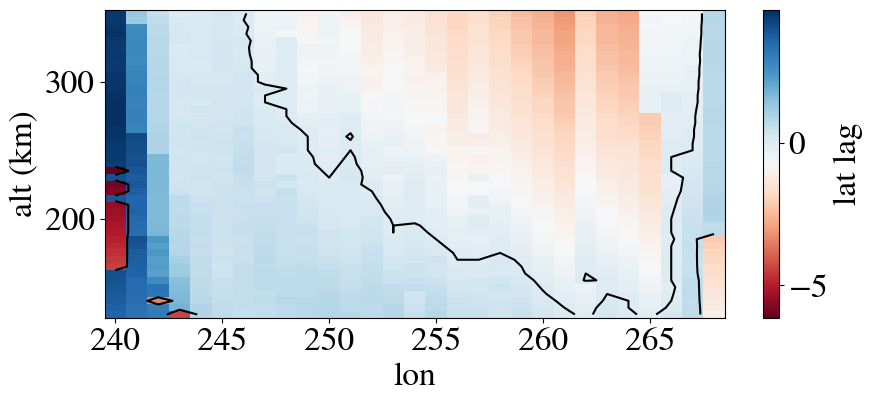

In [33]:
alts = np.array(h_target_arr) / 1000
fig, ax = plt.subplots(figsize=(10, 4))
m = ax.pcolormesh(global_lon_arr, alts, lat_lag_matrix, shading='auto', cmap='RdBu')
ax.contour(global_lon_arr, alts, lat_lag_matrix, levels=[0], colors='k')
plt.colorbar(m, label='lat lag'); ax.set_xlabel('lon'); ax.set_ylabel('alt (km)')